In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
clients = pd.read_csv('clients.csv')

In [16]:
clients.drop(columns=['Unnamed: 0'], inplace=True)

In [17]:
clients

,date_from,client_id,no_transactions,vol_transactions,churs_us,churn_os
0,2023-01-01,1,6476,24150,0,0
1,2023-02-01,1,9758,68956,0,1
2,2023-03-01,1,843,294,0,1
3,2023-04-01,1,9855,991,0,1
4,2023-05-01,1,4215,93504,0,1
...,...,...,...,...,...,...
745,2023-11-01,50,897,218,0,1
746,2023-12-01,50,4804,100728,0,1
747,2024-01-01,50,552,244,0,1
748,2024-02-01,50,7805,101682,1,1


## Standardization si Scalling

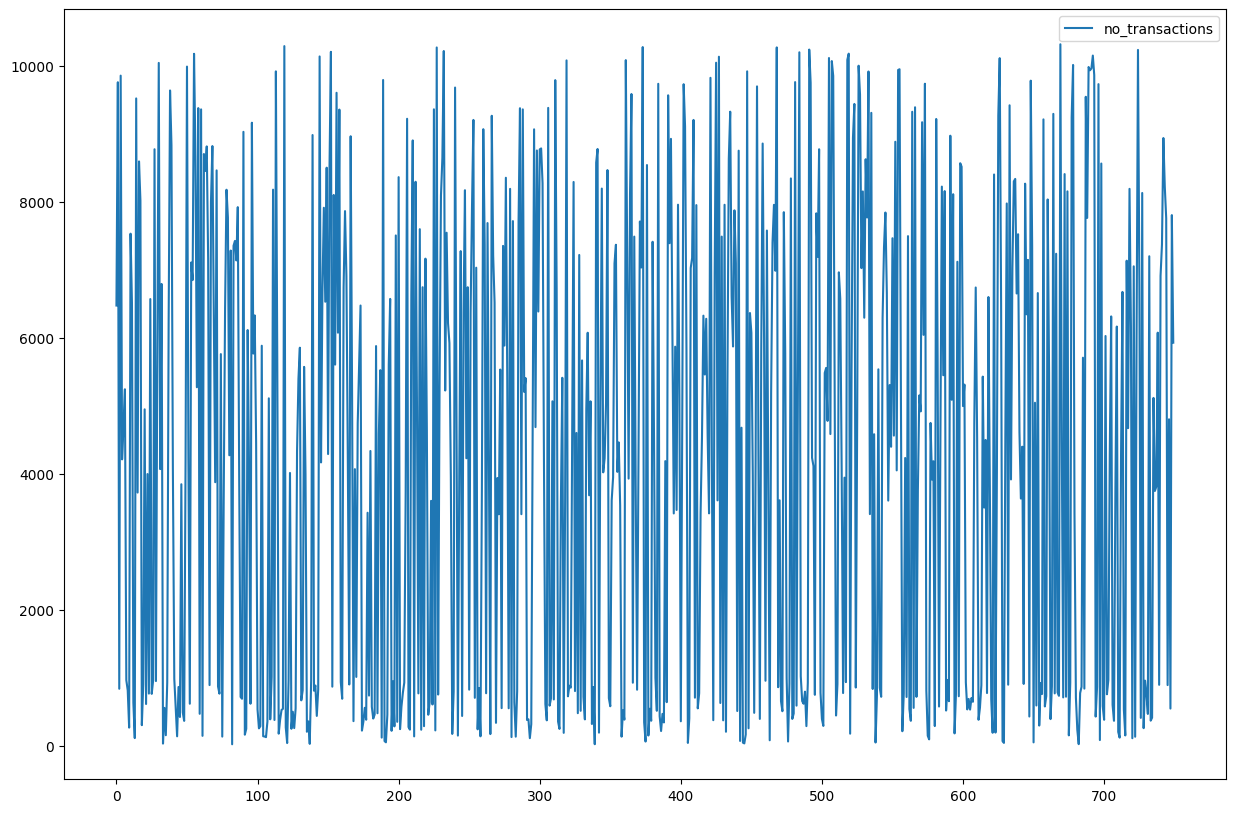

In [15]:
clients.plot(y='no_transactions', kind='line', figsize=(15, 10))
plt.show()

In [18]:
## De ce e bine sa scalam datele?
## Diferentele prea mari intre valori pot genera instabilitate numerica in cadrul antrenarii modelului
## Daca unele caracteristici au valori mult mai mari fata de celelalte, acestea vor domina in procesul de antrenare, si astfel vor reduce importanta caracteristicilor cu valori mai mici

In [19]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [20]:
scaler = StandardScaler()
standard_no_tran = scaler.fit_transform(clients[['no_transactions']])
## Alternativaplicam formula: (clients['no_transactions'] - clients['no_transactions'].mean())/ clients['no_transactions'].std()

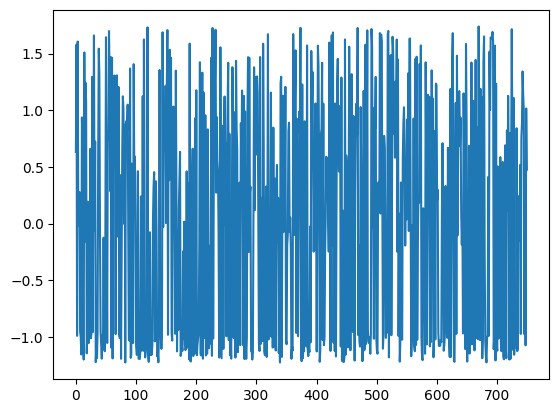

In [21]:
plt.plot(standard_no_tran)
plt.show()

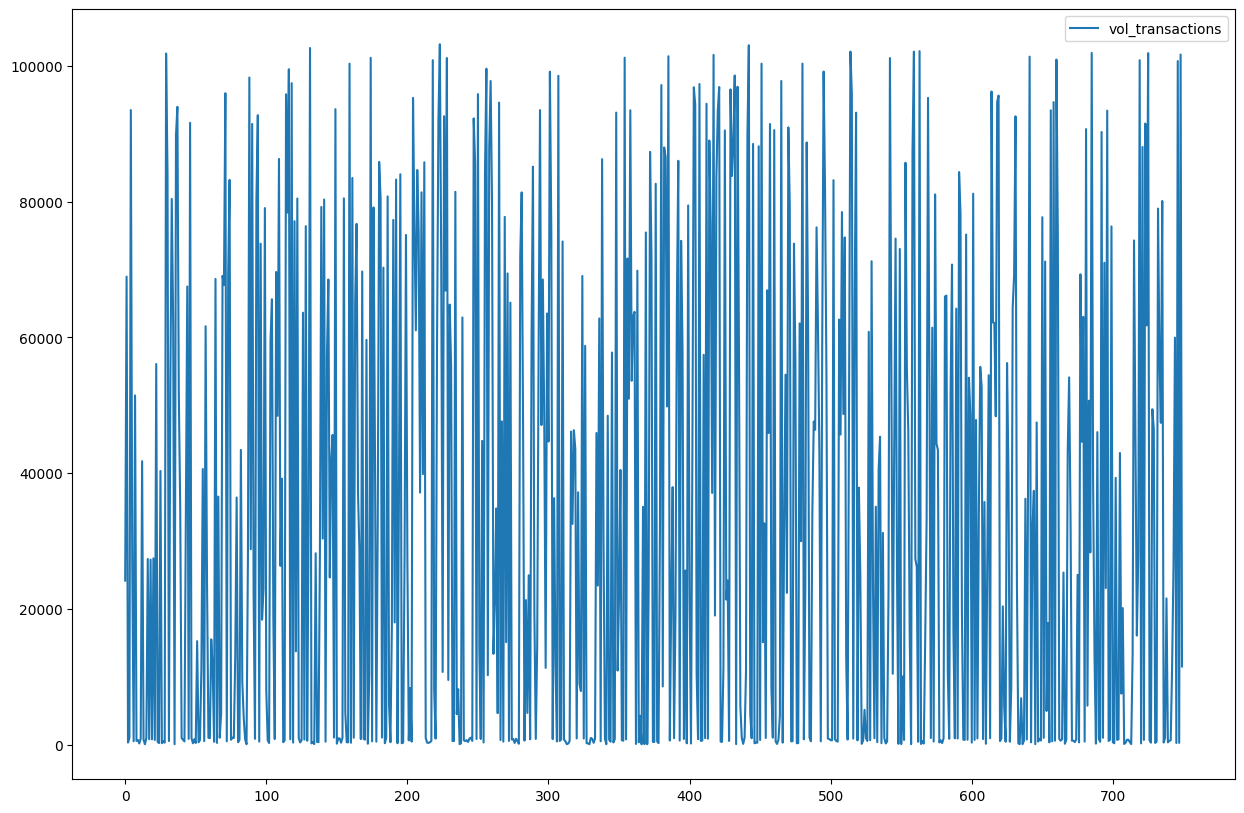

In [22]:
clients.plot(y='vol_transactions', kind='line', figsize=(15, 10))
plt.show()

In [23]:
min_max_scaler = MinMaxScaler()
mix_max_vol_trans = min_max_scaler.fit_transform(clients[['vol_transactions']])
## Alternativ folosim formula: (clients['vol_transactions'] - clients['vol_transactions'].min()) / (clients['vol_transactions'].max() - clients['vol_transactions'].min())

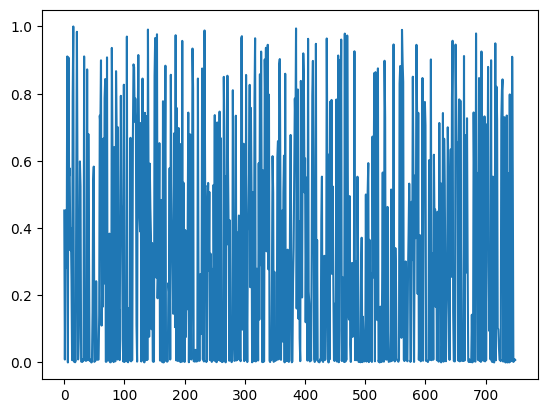

In [ ]:
plt.plot(mix_max_vol_trans)
plt.show()

In [24]:
clients.loc[:, 'no_transactions'] = standard_no_tran
clients.loc[:, 'vol_transactions'] = mix_max_vol_trans

/tmp/ipykernel_6238/218025599.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 6.32450621e-01  1.57875761e+00 -9.91725884e-01  1.60672586e+00
 -1.94689737e-02  1.22390576e-01  2.77513416e-01 -9.55107667e-01
 -9.98357530e-01 -1.15636369e+00  9.36929654e-01  6.43407253e-01
 -1.05112236e+00 -1.20076689e+00  1.51013450e+00 -1.60175193e-01
  1.24313868e+00  1.07677088e+00 -1.14598373e+00 -9.74137607e-01
  1.92455353e-01 -1.05631235e+00 -8.17487758e-02 -1.01219749e+00
  6.59842201e-01 -1.01335082e+00 -9.56837662e-01  1.29475018e+00
 -9.59144321e-01  4.70696135e-01  1.66064402e+00 -6.07005093e-02
  7.23851998e-01 -1.22412181e+00 -1.07274729e+00 -1.18865693e+00
 -9.64910969e-01  5.60655850e-01  1.54386939e+00  1.31205013e+00
 -6.18538390e-02 -9.49629351e-01 -1.07361229e+00 -1.19327024e+00
 -9.84229241e-01 -1.11138384e+00 -1.24998638e-01 -1.09177723e+00
 -1.12781879e+00 -1.83156440e-02  1.64507407e+00 -5.05235283e-03
 

In [25]:
clients

,date_from,client_id,no_transactions,vol_transactions,churs_us,churn_os
0,2023-01-01,1,0.632451,0.233756,0,0
1,2023-02-01,1,1.578758,0.668079,0,1
2,2023-03-01,1,-0.991726,0.002511,0,1
3,2023-04-01,1,1.606726,0.009267,0,1
4,2023-05-01,1,-0.019469,0.906032,0,1
...,...,...,...,...,...,...
745,2023-11-01,50,-0.976156,0.001774,0,1
746,2023-12-01,50,0.150359,0.976057,0,1
747,2024-01-01,50,-1.075631,0.002026,0,1
748,2024-02-01,50,1.015644,0.985305,1,1


## Undersampling

In [26]:
clients.loc[:, ~clients.columns.isin(['churn_os'])]

,date_from,client_id,no_transactions,vol_transactions,churs_us
0,2023-01-01,1,0.632451,0.233756,0
1,2023-02-01,1,1.578758,0.668079,0
2,2023-03-01,1,-0.991726,0.002511,0
3,2023-04-01,1,1.606726,0.009267,0
4,2023-05-01,1,-0.019469,0.906032,0
...,...,...,...,...,...
745,2023-11-01,50,-0.976156,0.001774,0
746,2023-12-01,50,0.150359,0.976057,0
747,2024-01-01,50,-1.075631,0.002026,0
748,2024-02-01,50,1.015644,0.985305,1


In [30]:
clients_us = clients.loc[:, ~clients.columns.isin(['churs_os'])]

In [31]:
clients_us.loc[:, 'churs_os'] = clients_us.churs_us.astype('str')

[]

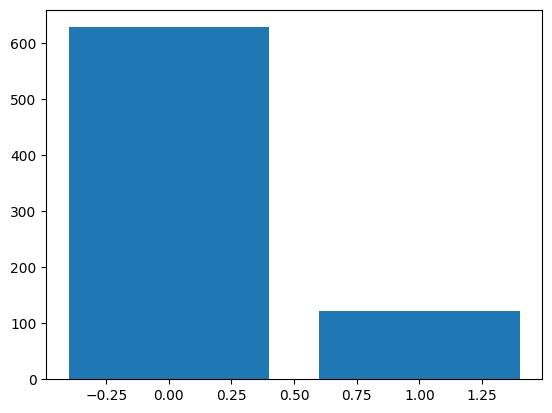

In [32]:
plt.bar(x = clients_us.churs_us.value_counts().index, height = clients_us.churs_us.value_counts().values)
plt.plot()

In [33]:
clients_us.churs_us.value_counts()

,count
churs_us,
0,628
1,122


In [ ]:
## Vreau sa reduc numarul de date care are eticheta 0 cu cel al datelor care au eticheta 1

In [ ]:
## Random Undersampling
## Selecteaza valori aleatorii din clasa majoritara in numar al clasei minoritare
## Avatanje
## Este rapid (pe langa faptul ca ne reduce setul de date)
## Poate elimina informatii utile din clasa majoritara
## Nu putem controla ce informatie se elimina -> poate limita generalizarea modelului

In [34]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler()
X = clients_us.drop(columns=['churs_us'])
y = clients_us.churs_us
X_resampled, y_resampled = rus.fit_resample(X, y)

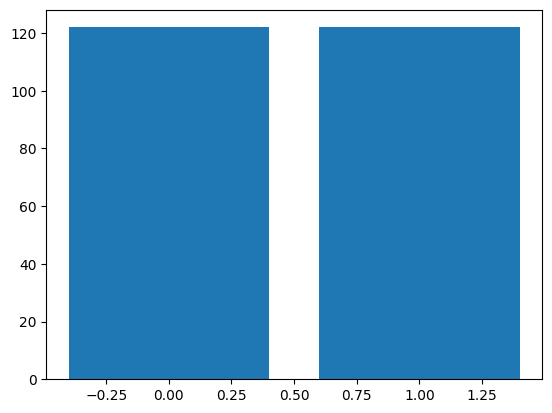

In [35]:
plt.bar(x=y_resampled.value_counts().index, height=y_resampled.value_counts().values)
plt.show()

In [ ]:
## Undersample cu Tomek Links
## Elimina exemplele din clasa majoritara care sunt cele mai apropiate (in termen de distanta) de exemplele din clasa minoritara
## Avantaje
## Pastreaza exemplele informative ale clasei majoritare
## Defineste o separabilitate mai buna intre clase
## Dezavantaje
## Lenta pentru seturi mari de date
## Nu reduce de cele mai multe ori dimensiunea datelor cu un numar semnificativ

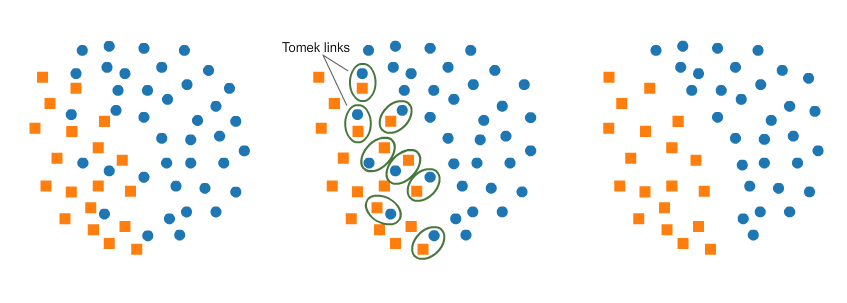

In [36]:
from imblearn.under_sampling import TomekLinks

t1 = TomekLinks()
X = clients_us.drop(columns=['churs_us', 'date_from', 'client_id'])
y = clients_us.churs_us
X_resampled, y_resampled = t1.fit_resample(X, y)

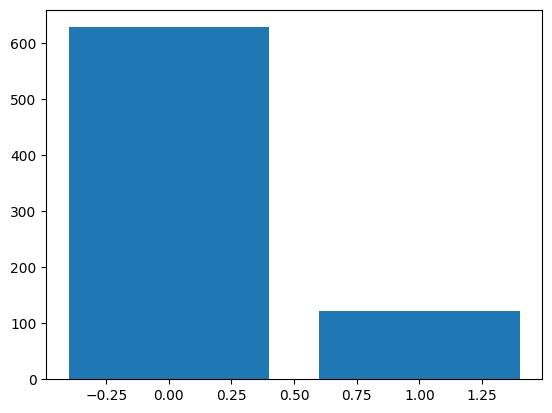

In [37]:
plt.bar(x=y_resampled.value_counts().index, height=y_resampled.value_counts().values)
plt.show()

In [38]:
y_resampled.value_counts()

,count
churs_us,
0,628
1,122


In [39]:
## Near Miss
## Este o metoda bazata pe distante care pastreaza doar exemplele din clasa majoritara care sunt cele mai apropiate de clasa minoritara
## Avantaje
## Pastreaza exemplele apropiate de granita de decizie (ajuta modelul sa generalizele mai bine)
## Este lent
## Poate pierde din exemple semnificative din clasa majoritara

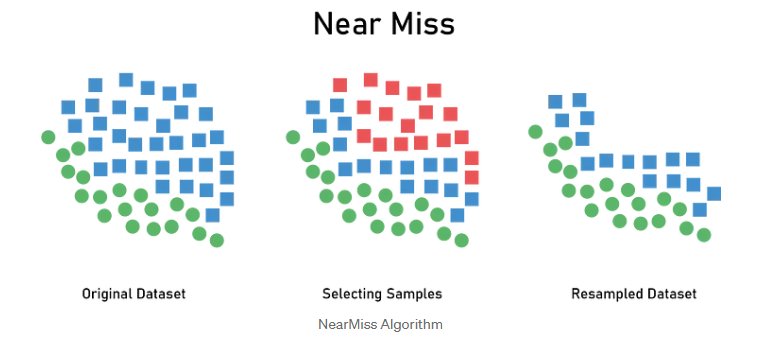

In [40]:
from imblearn.under_sampling import NearMiss
nm = NearMiss(version=1)
X = clients_us.drop(columns=['churs_us', 'date_from', 'client_id'])
y = clients_us.churs_us
X_resampled, y_resampled = nm.fit_resample(X, y)

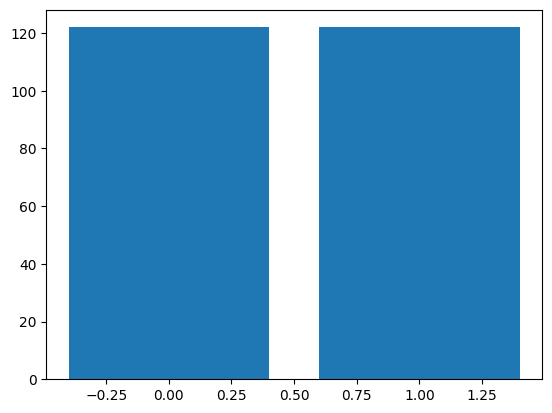

In [41]:
plt.bar(x=y_resampled.value_counts().index, height=y_resampled.value_counts().values)
plt.show()

## Oversampling

In [ ]:
## SMOTE (Synthetic Minority Oversampling Technique)
## Genereaza exemple noi sintetice prin interpolare liniara intre exemplele din clasa minoritara
## Avantaje
## Introduce diversitate in clasa minoritara
## Dezavantaje
## Poate genera exemple care nu reflecta bine distributia datelor
## Poate duce la crearea de exemple sintetice in zona de separare intre clase

In [42]:
clients

,date_from,client_id,no_transactions,vol_transactions,churs_us,churn_os
0,2023-01-01,1,0.632451,0.233756,0,0
1,2023-02-01,1,1.578758,0.668079,0,1
2,2023-03-01,1,-0.991726,0.002511,0,1
3,2023-04-01,1,1.606726,0.009267,0,1
4,2023-05-01,1,-0.019469,0.906032,0,1
...,...,...,...,...,...,...
745,2023-11-01,50,-0.976156,0.001774,0,1
746,2023-12-01,50,0.150359,0.976057,0,1
747,2024-01-01,50,-1.075631,0.002026,0,1
748,2024-02-01,50,1.015644,0.985305,1,1


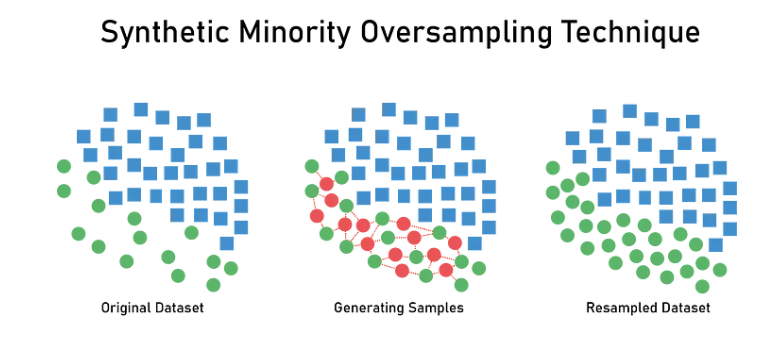

In [43]:
clients_os = clients.drop(columns=['churs_us'])


In [44]:
clients_os

,date_from,client_id,no_transactions,vol_transactions,churn_os
0,2023-01-01,1,0.632451,0.233756,0
1,2023-02-01,1,1.578758,0.668079,1
2,2023-03-01,1,-0.991726,0.002511,1
3,2023-04-01,1,1.606726,0.009267,1
4,2023-05-01,1,-0.019469,0.906032,1
...,...,...,...,...,...
745,2023-11-01,50,-0.976156,0.001774,1
746,2023-12-01,50,0.150359,0.976057,1
747,2024-01-01,50,-1.075631,0.002026,1
748,2024-02-01,50,1.015644,0.985305,1


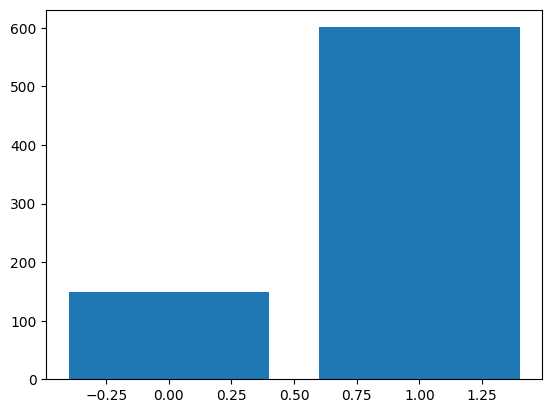

In [45]:
plt.bar(x=clients_os.churn_os.value_counts().index, height=clients_os.churn_os.value_counts().values)
plt.show()

In [46]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X = clients_us.drop(columns=['churn_os', 'date_from', 'client_id'])
y = clients_us.churn_os
X_resampled, y_resampled = smote.fit_resample(X, y)

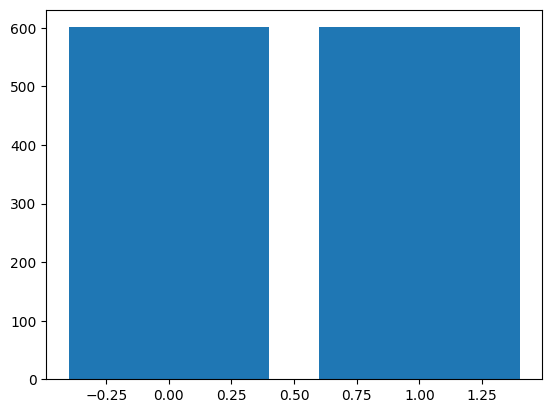

In [47]:
plt.bar(x=y_resampled.value_counts().index, height=y_resampled.value_counts().values)
plt.show()

In [ ]:
## ADASYN (Adaptive Synthetic Sampling)
## O alta varianta a SMOTE, genereaza mai multe exemple sintetice in zonele in care clasa minoritara este subreprezentata si mai putine in zonele unde densitatea este mare
## Avantaje
## Reduce decalajul intre clase
## Dezavantaje
## Este lent
## Poate genera exemple care nu reflecta bine distributia datelor

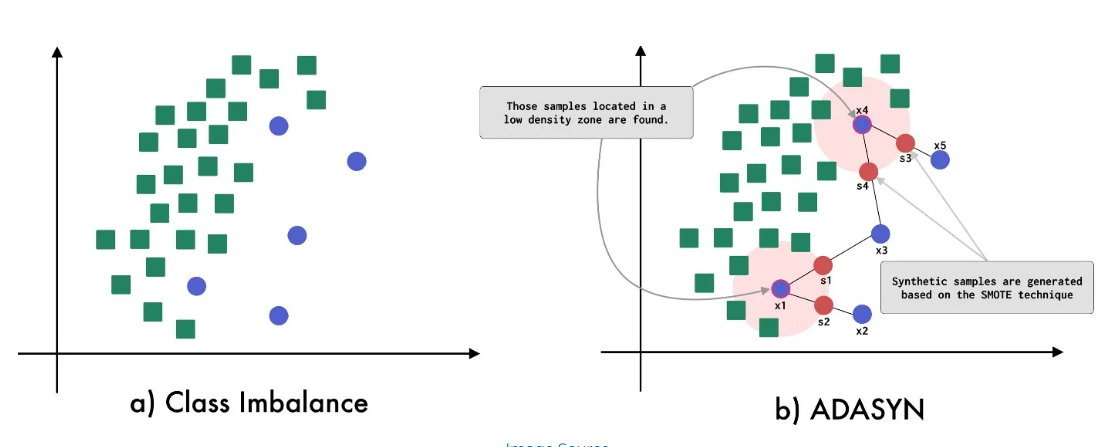

In [48]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X = clients_us.drop(columns=['churn_os', 'date_from', 'client_id'])
y = clients_us.churn_os
X_resampled, y_resampled = adasyn.fit_resample(X, y)